# IT2011 Artificial Intelligence and Machine Learning
## King County House Price Prediction
### Individual Preprocessing Technique: Feature Engineering

**Objective:**  
The purpose of this notebook is to perform feature engineering on the King County House Sales dataset by deriving meaningful new features from the existing variables. The engineered features aim to represent temporal information, property age, renovation status, basement characteristics, and relative property size more effectively.

The original dataset contains **21,613 observations and 21 variables**.  
After feature engineering, **10 new features** were created, resulting in **31 variables** while preserving all observations.


In [ ]:
# Feature Engineering - King County House Sales Dataset

## IT2011 Artificial Intelligence and Machine Learning

### Preprocessing Technique: Feature Engineering

###The objective of this notebook is to derive meaningful features from
###existing variables in the King County House Sales Dataset to improve
###the representation of property characteristics for machine learning.

###The target variable is `price`. The target variable will not be used
###to construct predictor features in order to prevent data leakage.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

print("Libraries imported successfully!")

Libraries imported successfully!


In [ ]:
import pandas as pd

df = pd.read_csv('/content/kc_house_data.csv')

print("Dataset loaded successfully!")
print("Shape:", df.shape)

df.head()

Dataset loaded successfully!
Shape: (21613, 21)


,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,3,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,3,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,3,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,5,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,3,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


In [ ]:
print("Column names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

print("\nNumber of duplicate rows:")
print(df.duplicated().sum())

Column names:
['id', 'date', 'price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'grade', 'sqft_above', 'sqft_basement', 'yr_built', 'yr_renovated', 'zipcode', 'lat', 'long', 'sqft_living15', 'sqft_lot15']

Data types:
id                 int64
date              object
price            float64
bedrooms           int64
bathrooms        float64
sqft_living        int64
sqft_lot           int64
floors           float64
waterfront         int64
view               int64
condition          int64
grade              int64
sqft_above         int64
sqft_basement      int64
yr_built           int64
yr_renovated       int64
zipcode            int64
lat              float64
long             float64
sqft_living15      int64
sqft_lot15         int64
dtype: object

Missing values:
id               0
date             0
price            0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0


In [ ]:
# Keep the original dataframe unchanged
df_fe = df.copy()

# Convert the date column from object/string to datetime
df_fe['date'] = pd.to_datetime(
    df_fe['date'],
    format='%Y%m%dT%H%M%S'
)

print("Date converted successfully!")
print("Old type :", df['date'].dtype)
print("New type :", df_fe['date'].dtype)

print("\nExample dates:")
display(df_fe[['date']].head())

Date converted successfully!
Old type : object
New type : datetime64[ns]

Example dates:


,date
0,2014-10-13
1,2014-12-09
2,2015-02-25
3,2014-12-09
4,2015-02-18


In [ ]:
# Extract useful information from the sale date

df_fe['sale_year'] = df_fe['date'].dt.year
df_fe['sale_month'] = df_fe['date'].dt.month

print("New date-based features created!")

display(
    df_fe[['date', 'sale_year', 'sale_month']].head()
)

New date-based features created!


,date,sale_year,sale_month
0,2014-10-13,2014,10
1,2014-12-09,2014,12
2,2015-02-25,2015,2
3,2014-12-09,2014,12
4,2015-02-18,2015,2


In [ ]:
# Create house age at the time the property was sold
df_fe['house_age'] = df_fe['sale_year'] - df_fe['yr_built']

print("House age feature created!")

print("Minimum house age:", df_fe['house_age'].min())
print("Maximum house age:", df_fe['house_age'].max())

display(
    df_fe[['sale_year', 'yr_built', 'house_age']].head(10)
)

House age feature created!
Minimum house age: -1
Maximum house age: 115


,sale_year,yr_built,house_age
0,2014,1955,59
1,2014,1951,63
2,2015,1933,82
3,2014,1965,49
4,2015,1987,28
5,2014,2001,13
6,2014,1995,19
7,2015,1963,52
8,2015,1960,55
9,2015,2003,12


In [ ]:
# Investigate records where the calculated house age is negative

negative_age = df_fe[df_fe['house_age'] < 0]

print("Number of houses with negative age:", len(negative_age))

display(
    negative_age[
        ['date', 'sale_year', 'yr_built', 'house_age', 'price', 'zipcode']
    ]
)

Number of houses with negative age: 12


,date,sale_year,yr_built,house_age,price,zipcode
1763,2014-06-25,2014,2015,-1,597326.0,98040
2687,2014-10-29,2014,2015,-1,385195.0,98144
7526,2014-12-31,2014,2015,-1,614285.0,98072
8039,2014-06-24,2014,2015,-1,455000.0,98144
14489,2014-08-26,2014,2015,-1,500000.0,98199
17098,2014-06-17,2014,2015,-1,350000.0,98122
19805,2014-08-01,2014,2015,-1,455000.0,98122
20770,2014-08-28,2014,2015,-1,357000.0,98133
20852,2014-07-09,2014,2015,-1,595000.0,98103
20963,2014-07-31,2014,2015,-1,230000.0,98144


In [ ]:
# Correct logically invalid negative house ages
df_fe['house_age'] = df_fe['house_age'].clip(lower=0)

print("Negative house ages corrected!")

print("Minimum house age:", df_fe['house_age'].min())
print("Maximum house age:", df_fe['house_age'].max())

print("Number of negative ages remaining:",
      (df_fe['house_age'] < 0).sum())

Negative house ages corrected!
Minimum house age: 0
Maximum house age: 115
Number of negative ages remaining: 0


In [ ]:
# Inspect the renovation-year feature before engineering new variables

never_renovated = (df_fe['yr_renovated'] == 0).sum()
renovated = (df_fe['yr_renovated'] > 0).sum()

print("Never renovated:", never_renovated)
print("Renovated:", renovated)

print("\nPercentage renovated:",
      round((renovated / len(df_fe)) * 100, 2), "%")

# Check the renovation years only for houses that were actually renovated
renovation_years = df_fe.loc[
    df_fe['yr_renovated'] > 0,
    'yr_renovated'
]

print("\nEarliest renovation year:", renovation_years.min())
print("Latest renovation year:", renovation_years.max())

# Check whether any recorded renovation happened after the sale year
invalid_renovation = df_fe[
    (df_fe['yr_renovated'] > 0) &
    (df_fe['yr_renovated'] > df_fe['sale_year'])
]

print("\nRenovations recorded after sale:",
      len(invalid_renovation))

Never renovated: 20699
Renovated: 914

Percentage renovated: 4.23 %

Earliest renovation year: 1934
Latest renovation year: 2015

Renovations recorded after sale: 6


In [ ]:
# Inspect records where renovation year is after the sale year

display(
    invalid_renovation[
        [
            'date',
            'sale_year',
            'yr_built',
            'yr_renovated',
            'price',
            'zipcode'
        ]
    ]
)

,date,sale_year,yr_built,yr_renovated,price,zipcode
2295,2014-07-28,2014,1922,2015,585000.0,98112
7097,2014-10-28,2014,1940,2015,285000.0,98133
11599,2014-05-22,2014,1923,2015,850000.0,98177
14859,2014-06-06,2014,1956,2015,805000.0,98177
15687,2014-10-06,2014,1955,2015,825000.0,98177
18575,2014-07-01,2014,1945,2015,476000.0,98115


In [ ]:
# A renovation is valid for prediction only if it happened
# before or during the year the house was sold
valid_renovation = (
    (df_fe['yr_renovated'] > 0) &
    (df_fe['yr_renovated'] <= df_fe['sale_year'])
)

# Feature 1: Was the house renovated by the time of sale?
df_fe['has_renovation'] = valid_renovation.astype(int)

# Feature 2: How many years had passed since renovation?
# Use 0 for houses that had not been renovated by the time of sale
df_fe['renovation_age'] = np.where(
    valid_renovation,
    df_fe['sale_year'] - df_fe['yr_renovated'],
    0
)

print("Renovation features created!")

print("Houses renovated by sale:",
      df_fe['has_renovation'].sum())

print("Minimum renovation age:",
      df_fe['renovation_age'].min())

print("Maximum renovation age:",
      df_fe['renovation_age'].max())

display(
    df_fe[
        [
            'sale_year',
            'yr_renovated',
            'has_renovation',
            'renovation_age'
        ]
    ].head(10)
)

Renovation features created!
Houses renovated by sale: 908
Minimum renovation age: 0
Maximum renovation age: 80


,sale_year,yr_renovated,has_renovation,renovation_age
0,2014,0,0,0
1,2014,1991,1,23
2,2015,0,0,0
3,2014,0,0,0
4,2015,0,0,0
5,2014,0,0,0
6,2014,0,0,0
7,2015,0,0,0
8,2015,0,0,0
9,2015,0,0,0


In [ ]:
# Create a feature representing living space relative to lot size

df_fe['living_lot_ratio'] = (
    df_fe['sqft_living'] / df_fe['sqft_lot']
)

print("Living-to-lot ratio feature created!")

print("Minimum ratio:", df_fe['living_lot_ratio'].min())
print("Maximum ratio:", df_fe['living_lot_ratio'].max())

display(
    df_fe[
        ['sqft_living', 'sqft_lot', 'living_lot_ratio']
    ].head(10)
)

Living-to-lot ratio feature created!
Minimum ratio: 0.0006095498431482305
Maximum ratio: 4.653846153846154


,sqft_living,sqft_lot,living_lot_ratio
0,1180,5650,0.208850
1,2570,7242,0.354874
2,770,10000,0.077000
3,1960,5000,0.392000
4,1680,8080,0.207921
5,5420,101930,0.053174
6,1715,6819,0.251503
7,1060,9711,0.109155
8,1780,7470,0.238286
9,1890,6560,0.288110


In [ ]:
# Create a binary feature indicating whether the house has a basement

df_fe['has_basement'] = (
    df_fe['sqft_basement'] > 0
).astype(int)

print("Basement feature created!")

print("Houses without basement:",
      (df_fe['has_basement'] == 0).sum())

print("Houses with basement:",
      (df_fe['has_basement'] == 1).sum())

display(
    df_fe[
        ['sqft_basement', 'has_basement']
    ].head(10)
)

Basement feature created!
Houses without basement: 13126
Houses with basement: 8487


,sqft_basement,has_basement
0,0,0
1,400,1
2,0,0
3,910,1
4,0,0
5,1530,1
6,0,0
7,0,0
8,730,1
9,0,0


In [ ]:
# Create basement area as a proportion of total living area

df_fe['basement_ratio'] = np.where(
    df_fe['sqft_living'] > 0,
    df_fe['sqft_basement'] / df_fe['sqft_living'],
    0
)

print("Basement ratio feature created!")

print("Minimum basement ratio:",
      df_fe['basement_ratio'].min())

print("Maximum basement ratio:",
      df_fe['basement_ratio'].max())

display(
    df_fe[
        ['sqft_living', 'sqft_basement', 'basement_ratio']
    ].head(10)
)

Basement ratio feature created!
Minimum basement ratio: 0.0
Maximum basement ratio: 0.6666666666666666


,sqft_living,sqft_basement,basement_ratio
0,1180,0,0.000000
1,2570,400,0.155642
2,770,0,0.000000
3,1960,910,0.464286
4,1680,0,0.000000
5,5420,1530,0.282288
6,1715,0,0.000000
7,1060,0,0.000000
8,1780,730,0.410112
9,1890,0,0.000000


In [ ]:
# Compare the property's living area with sqft_living15

df_fe['living_size_ratio'] = np.where(
    df_fe['sqft_living15'] > 0,
    df_fe['sqft_living'] / df_fe['sqft_living15'],
    0
)

print("Living size ratio feature created!")

print("Minimum living size ratio:",
      df_fe['living_size_ratio'].min())

print("Maximum living size ratio:",
      df_fe['living_size_ratio'].max())

display(
    df_fe[
        ['sqft_living', 'sqft_living15', 'living_size_ratio']
    ].head(10)
)

Living size ratio feature created!
Minimum living size ratio: 0.17901234567901234
Maximum living size ratio: 6.0


,sqft_living,sqft_living15,living_size_ratio
0,1180,1340,0.880597
1,2570,1690,1.520710
2,770,2720,0.283088
3,1960,1360,1.441176
4,1680,1800,0.933333
5,5420,4760,1.138655
6,1715,2238,0.766309
7,1060,1650,0.642424
8,1780,1780,1.000000
9,1890,2390,0.790795


In [ ]:
# Inspect the houses with the highest living-size ratios

display(
    df_fe[
        [
            'sqft_living',
            'sqft_living15',
            'living_size_ratio',
            'price',
            'zipcode'
        ]
    ]
    .sort_values('living_size_ratio', ascending=False)
    .head(10)
)

,sqft_living,sqft_living15,living_size_ratio,price,zipcode
17286,2760,460,6.000000,378000.0,98125
13441,2290,399,5.739348,536000.0,98042
20452,6530,1280,5.101562,1600000.0,98014
20471,6370,1490,4.275168,1800000.0,98027
21506,7270,1800,4.038889,2238890.0,98027
3771,2780,720,3.861111,449900.0,98198
4255,3902,1100,3.547273,1300000.0,98116
6577,3420,980,3.489796,908800.0,98144
11787,4340,1290,3.364341,1280000.0,98199
11053,3020,900,3.355556,354000.0,98178


In [ ]:
# Compare the property's lot size with the nearby lot-size reference

df_fe['lot_size_ratio'] = np.where(
    df_fe['sqft_lot15'] > 0,
    df_fe['sqft_lot'] / df_fe['sqft_lot15'],
    0
)

print("Lot size ratio feature created!")

print("Minimum lot size ratio:",
      df_fe['lot_size_ratio'].min())

print("Maximum lot size ratio:",
      df_fe['lot_size_ratio'].max())

display(
    df_fe[
        ['sqft_lot', 'sqft_lot15', 'lot_size_ratio']
    ].head(10)
)

Lot size ratio feature created!
Minimum lot size ratio: 0.054971997700810314
Maximum lot size ratio: 87.52717948717948


,sqft_lot,sqft_lot15,lot_size_ratio
0,5650,5650,1.000000
1,7242,7639,0.948030
2,10000,8062,1.240387
3,5000,5000,1.000000
4,8080,7503,1.076903
5,101930,101930,1.000000
6,6819,6819,1.000000
7,9711,9711,1.000000
8,7470,8113,0.920744
9,6560,7570,0.866579


In [ ]:
# Inspect properties with the highest lot-size ratios

display(
    df_fe[
        [
            'sqft_lot',
            'sqft_lot15',
            'lot_size_ratio',
            'price',
            'zipcode'
        ]
    ]
    .sort_values('lot_size_ratio', ascending=False)
    .head(10)
)

,sqft_lot,sqft_lot15,lot_size_ratio,price,zipcode
7769,1024068,11700,87.527179,855000.0,98045
17319,1164794,16730,69.623072,190000.0,98014
17232,158558,3572,44.389138,280000.0,98065
13944,81892,1863,43.957059,360000.0,98055
14952,288367,8154,35.365097,295000.0,98042
10526,323215,9891,32.677687,1565000.0,98075
3455,290980,9255,31.440303,1290000.0,98034
6501,223462,7593,29.430001,1940000.0,98053
5977,169448,6059,27.966331,306000.0,98030
4399,262666,9791,26.827290,1150000.0,98075


In [ ]:
# List all engineered features created

engineered_features = [
    'sale_year',
    'sale_month',
    'house_age',
    'has_renovation',
    'renovation_age',
    'living_lot_ratio',
    'has_basement',
    'basement_ratio',
    'living_size_ratio',
    'lot_size_ratio'
]

print("Number of engineered features:", len(engineered_features))

print("\nDataset shape before Feature Engineering:", df.shape)
print("Dataset shape after Feature Engineering :", df_fe.shape)

# Check for missing values
print("\nMissing values in engineered features:")
print(df_fe[engineered_features].isnull().sum())

# Check for infinite values
print("\nInfinite values in engineered features:")
print(
    np.isinf(df_fe[engineered_features])
    .sum()
)

# Preview the engineered features
display(df_fe[engineered_features].head())

Number of engineered features: 10

Dataset shape before Feature Engineering: (21613, 21)
Dataset shape after Feature Engineering : (21613, 31)

Missing values in engineered features:
sale_year            0
sale_month           0
house_age            0
has_renovation       0
renovation_age       0
living_lot_ratio     0
has_basement         0
basement_ratio       0
living_size_ratio    0
lot_size_ratio       0
dtype: int64

Infinite values in engineered features:
sale_year            0
sale_month           0
house_age            0
has_renovation       0
renovation_age       0
living_lot_ratio     0
has_basement         0
basement_ratio       0
living_size_ratio    0
lot_size_ratio       0
dtype: int64


,sale_year,sale_month,house_age,has_renovation,renovation_age,living_lot_ratio,has_basement,basement_ratio,living_size_ratio,lot_size_ratio
0,2014,10,59,0,0,0.208850,0,0.000000,0.880597,1.000000
1,2014,12,63,1,23,0.354874,1,0.155642,1.520710,0.948030
2,2015,2,82,0,0,0.077000,0,0.000000,0.283088,1.240387
3,2014,12,49,0,0,0.392000,1,0.464286,1.441176,1.000000
4,2015,2,28,0,0,0.207921,0,0.000000,0.933333,1.076903


Correlation of engineered features with price:


,Correlation with Price
living_size_ratio,0.302192
has_basement,0.180230
basement_ratio,0.135539
has_renovation,0.126122
living_lot_ratio,0.123115
renovation_age,0.067193
lot_size_ratio,0.041843
sale_year,0.003576
sale_month,-0.010081
house_age,-0.053956


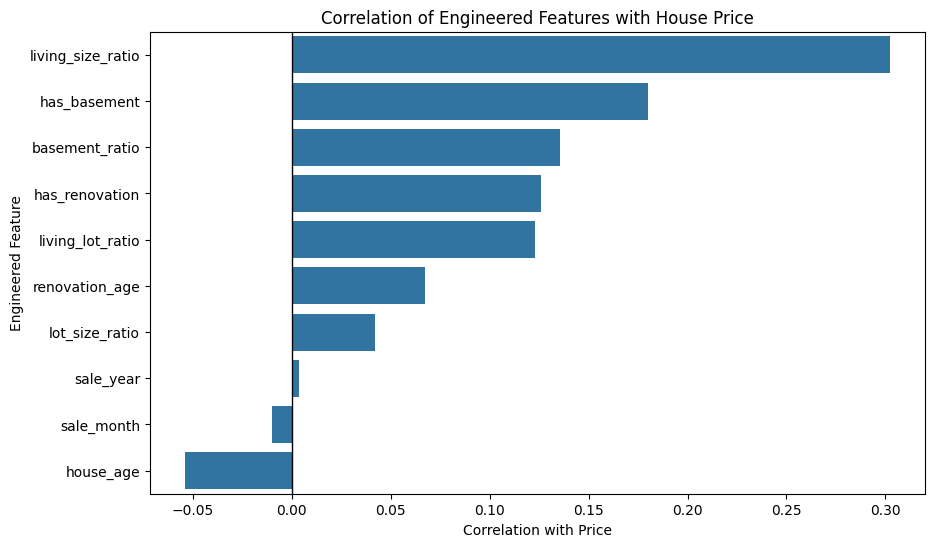

In [ ]:
# Check how the engineered features are related to house price

correlations = (
    df_fe[engineered_features + ['price']]
    .corr()['price']
    .drop('price')
    .sort_values(ascending=False)
)

print("Correlation of engineered features with price:")
display(correlations.to_frame(name='Correlation with Price'))

# Visualize the correlations
plt.figure(figsize=(10, 6))

sns.barplot(
    x=correlations.values,
    y=correlations.index
)

plt.title('Correlation of Engineered Features with House Price')
plt.xlabel('Correlation with Price')
plt.ylabel('Engineered Feature')

plt.axvline(0, color='black', linewidth=1)

plt.show()

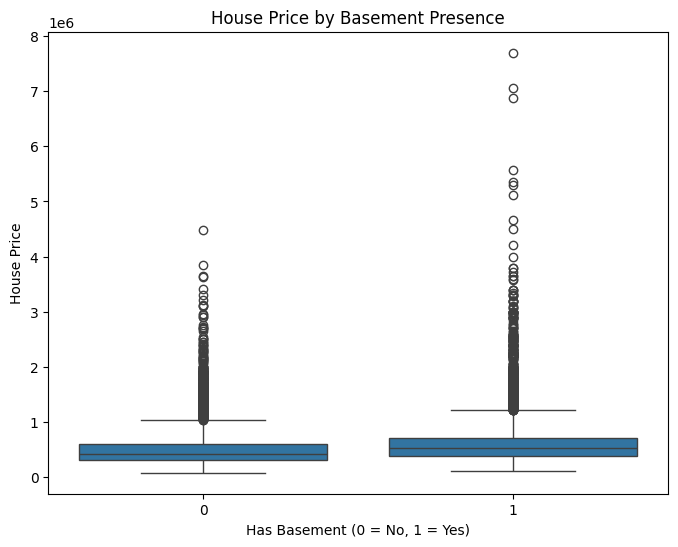

,count,mean,median
has_basement,,,
0,13126,486884.090507,411500.0
1,8487,622373.563803,515000.0


In [ ]:
# Compare house prices for properties with and without basements

plt.figure(figsize=(8, 6))

sns.boxplot(
    x='has_basement',
    y='price',
    data=df_fe
)

plt.title('House Price by Basement Presence')
plt.xlabel('Has Basement (0 = No, 1 = Yes)')
plt.ylabel('House Price')

plt.show()

# Show numerical summary as well
basement_price_summary = (
    df_fe.groupby('has_basement')['price']
    .agg(['count', 'mean', 'median'])
)

display(basement_price_summary)

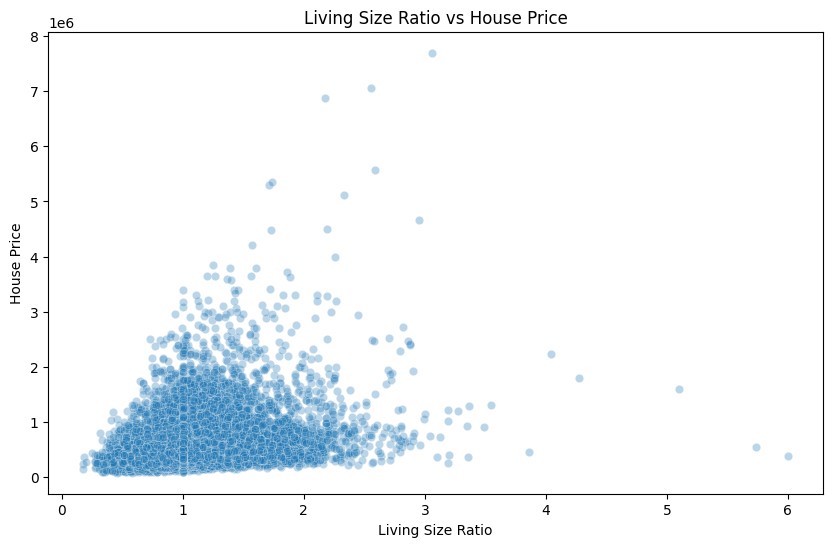

In [ ]:
# Visualize the relationship between relative living size and house price

plt.figure(figsize=(10, 6))

sns.scatterplot(
    x='living_size_ratio',
    y='price',
    data=df_fe,
    alpha=0.3
)

plt.title('Living Size Ratio vs House Price')
plt.xlabel('Living Size Ratio')
plt.ylabel('House Price')

plt.show()

In [ ]:
# Summary of original vs feature-engineered predictor sets
# These will be used later for model evaluation

from sklearn.model_selection import train_test_split

# Target variable
y = df_fe['price']

# Original numerical predictors
# Remove price because it is the target
# Remove id because it is only an identifier
# Remove date because Extra Trees cannot directly use datetime values
baseline_features = [
    col for col in df.columns
    if col not in ['price', 'id', 'date']
]

# Baseline dataset
X_baseline = df_fe[baseline_features]

# Feature-engineered dataset
X_engineered = df_fe[baseline_features + engineered_features]

print("Baseline number of features:", X_baseline.shape[1])
print("Engineered number of features:", X_engineered.shape[1])

print("\nBaseline shape:", X_baseline.shape)
print("Engineered shape:", X_engineered.shape)
print("Target shape:", y.shape)

Baseline number of features: 18
Engineered number of features: 28

Baseline shape: (21613, 18)
Engineered shape: (21613, 28)
Target shape: (21613,)


In [ ]:
# Summarize all engineered features and their purpose

feature_summary = pd.DataFrame({
    'Engineered Feature': [
        'sale_year',
        'sale_month',
        'house_age',
        'has_renovation',
        'renovation_age',
        'living_lot_ratio',
        'has_basement',
        'basement_ratio',
        'living_size_ratio',
        'lot_size_ratio'
    ],

    'Derived From': [
        'date',
        'date',
        'sale_year, yr_built',
        'yr_renovated, sale_year',
        'yr_renovated, sale_year',
        'sqft_living, sqft_lot',
        'sqft_basement',
        'sqft_basement, sqft_living',
        'sqft_living, sqft_living15',
        'sqft_lot, sqft_lot15'
    ],

    'Purpose': [
        'Capture the year in which the property was sold',
        'Capture possible seasonal effects in house sales',
        'Represent the age of the house at the time of sale',
        'Indicate whether the house had been renovated by the sale date',
        'Measure how long ago the renovation occurred',
        'Represent living area relative to total lot area',
        'Indicate whether a basement exists',
        'Represent basement area as a proportion of living area',
        'Represent house size relative to the local/reference living size',
        'Represent lot size relative to the local/reference lot size'
    ]
})

display(feature_summary)

,Engineered Feature,Derived From,Purpose
0,sale_year,date,Capture the year in which the property was sold
1,sale_month,date,Capture possible seasonal effects in house sales
2,house_age,"sale_year, yr_built",Represent the age of the house at the time of ...
3,has_renovation,"yr_renovated, sale_year",Indicate whether the house had been renovated ...
4,renovation_age,"yr_renovated, sale_year",Measure how long ago the renovation occurred
5,living_lot_ratio,"sqft_living, sqft_lot",Represent living area relative to total lot area
6,has_basement,sqft_basement,Indicate whether a basement exists
7,basement_ratio,"sqft_basement, sqft_living",Represent basement area as a proportion of liv...
8,living_size_ratio,"sqft_living, sqft_living15",Represent house size relative to the local/ref...
9,lot_size_ratio,"sqft_lot, sqft_lot15",Represent lot size relative to the local/refer...


In [ ]:
# Save the completed feature-engineered dataset

output_file = '/content/kc_house_feature_engineered.csv'

df_fe.to_csv(
    output_file,
    index=False
)

print("Feature-engineered dataset saved successfully!")
print("File:", output_file)
print("Final shape:", df_fe.shape)

Feature-engineered dataset saved successfully!
File: /content/kc_house_feature_engineered.csv
Final shape: (21613, 31)


In [ ]:
from google.colab import files

files.download('/content/kc_house_feature_engineered.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>